# Final Project - College to Pro: An NFL Draft Prospect Analysis

### Isaac Marr
### CSCI S-108 Data Mining, Discovery, and Exploration
### Harvard Extension School 
### Summer 2025

# Executive Summary

The goal of this project is to find a reliable method to match college quarterbacks with similar players to get a sense of possible career outcomes. Being able to find clusters or perform similarity searches of players could help find quarterbacks with top tier talent who are not being drafted highly. It could also help avoid quarterbacks who could underperform their draft position.

I combined three different datasets for this project. A dataset with the stats of every college quarterback who registered a statistic between 2004, a dataset containing every NFL quarterback who entered the league between 2005 and 2021 for results, and NFL combine data from 2000 to 2025. The NFL Combine data was too sparse to ultimately use in my analysis so I dropped it during clustering.

To prepare this data, I first merged the datasets. I then unskewed several columns and standardized the data on a zero to one scale. I used **FeatureHasher** from sklearn to hash the categorical columns. I then used **PCA** to reduce dimensionality of the hashed data.

I then applied clustering to my dataset using several different methods. I tried **agglomerative clustering**, **spectral clustering**, and **OPTICS**. Spectral clustering produced a cluster with a high success rate that I then did some additional analysis on.

Finally, I conducted a **similarity search using a flat index**. I wrote a function that allows you to search any quarterback in the dataset and return the top five most similar quarterbacks. Because my dataset was small enough to use a flat index without running into speed or memory issues, recall was 100%. 

Overall, I accomplished my goal of a reliable method to match college quarterbacks with similar players. I located a cluster of high performing quarterbacks that I can continue to analyze, and came up with a working similarity search function that works well from a recall perspective and also produces results that match my domain knowledge. 

# 1.0 Introduction
According to [The Athletic](https://www.nytimes.com/athletic/5377539/2024/03/29/odds-a-top-10-qb-busts-scoop-city/), 41% of Quarterbacks drafted in the first round of the NFL Draft can be classified as a reach or a bust. Quarterback is the most important position in football, and NFL teams pay handsomely for good ones with top QBs making more than $50 million per year according to [Spotrac](https://www.spotrac.com/nfl/rankings/player/_/year/2024/position/qb/sort/contract_average). Even a mediocre quarterback is often the "face of the franchise" as long as he is playing, and the drafting of a new quarterback is always a momentous occasion for the fanbase. Multi-billion dollar companies like NFL teams rarely make decisions based on a coin flip, but drafting a good quarterback has only slightly better odds. A solid quarterback can boost ticket and merchandise sales, a great one can bring a Super Bowl and even shift the financial fortunes of his host city. With this project, I will take a look at every quarterback who played a college snap from 2004 until 2020 and track their college stats, draft position, and NFL success. Using this data, I will develop similarity measures to compare future potential draft picks to past players. I will also explore cluster analysis to see which traits generally lead to NFL success.

# 2.0 Data
I am using three datasets that I have merged for this project.

1. I used the [cfbfastR](https://cfbfastr.sportsdataverse.org) R package to get a dataset with the stats of every college quarterback who registered a statistic between 2004 (the earliest year that the package can return) to 2020. I chose 2020 because I wanted a minumum of four seasons of NFL data to study outcomes.
2. I used the [nflreadr](https://nflreadr.nflverse.com/reference/index.html) R package to get NFL combine data from 2000 to 2025. The NFL Combine is a yearly event where the top college players are invited to Indianapolis to work out for NFL teams. Players typiclally compete in the bench press, 40 yard dash, vertical jump, and more.
3. I used the [Pro Football Reference](https://www.pro-football-reference.com) StatHead draft tools to generate a spreadsheet containing every NFL quarterback who entered the league between 2005 and 2021 with their draft position and some statistics. I am using Football Reference's AV metric as a way to judge career quality. You can read about that metric [here](https://www.pro-football-reference.com/about/approximate_value.htm).

See the appendix for an explanation of each column I used in my final analysis.

# 3.0 Data Loading and Cleaning

In [1405]:
import pandas as pd
import numpy as np
import string
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction import FeatureHasher
from sklearn.decomposition import PCA
import seaborn as sns
import numpy.random as nr
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering, DBSCAN, OPTICS, MiniBatchKMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.metrics.pairwise import pairwise_distances, cosine_similarity, cosine_distances, euclidean_distances 
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.neighbors import radius_neighbors_graph, kneighbors_graph
from patsy import dmatrix
import networkx as nx
import umap
import time
import math
import faiss

Loading the datasets that I pulled with R and from StatHead

In [1407]:
results_df = pd.read_excel("NFL Results Data.xlsx")
cfb_df = pd.read_csv("cfb_qb_stats_full_2004_2020.csv")
combine_df = pd.read_csv("combine_data.csv")

I'm not sure what I will end up using to classify a "successful" quarterback, so I am calculating AV per year so that quarterbacks whose careers are ongoing are not penalized by using cumulative AC. This may not be helpful because a quarterback that is a "success" should play for 15+ years anyway, but it will be good to have the option down the road.

In [1409]:
# Cleaning NFL Data
results_df["years_played"] = results_df["To"] - results_df["From"] + 1 # Calculating years played in career
results_df["av_per_year"] = results_df["AV"] / results_df["years_played"] # calculating AV/year for possible future use
results_df = results_df.drop(["Rk", "AV.1", "Pos"], axis=1) # Dropping redundant/unecessary columns
print(results_df.shape)
results_df.head(10)

(212, 15)


,Player,AV,Draft Team,Round,Pick,Draft Year,College,From,To,Age,G,GS,Team,years_played,av_per_year
0,Aaron Rodgers,243,GNB,1,24,2005,California,2005,2024,22-41,248,241,"GNB,NYJ",20,12.150000
1,Alex Smith,120,SFO,1,1,2005,Utah,2005,2020,21-36,174,167,"KAN,SFO,WAS",16,7.500000
2,Ryan Fitzpatrick,101,STL,7,250,2005,Harvard,2005,2021,23-39,166,147,"BUF,CIN,HOU,MIA,NYJ,STL,TAM,TEN,WAS",17,5.941176
3,Matt Cassel,51,NWE,7,230,2005,Southern California,2005,2018,23-36,107,81,"BUF,DAL,DET,KAN,MIN,NWE,TEN",14,3.642857
4,Kyle Orton,44,CHI,4,106,2005,Purdue,2005,2014,23-32,87,82,"BUF,CHI,DAL,DEN,KAN",10,4.400000
5,Seneca Wallace,16,SEA,4,110,2003,Iowa State,2005,2013,25-33,64,22,"CLE,GNB,SEA",9,1.777778
6,Charlie Frye,8,CLE,3,67,2005,Akron,2005,2009,24-28,26,23,"CLE,OAK,SEA",5,1.600000
7,Dan Orlovsky,7,DET,5,145,2005,Connecticut,2005,2015,22-32,26,12,"DET,HOU,IND,TAM",11,0.636364
8,Matt Mauck,1,DEN,7,225,2004,Louisiana State,2005,2005,26,2,1,TEN,1,1.000000
9,Kliff Kingsbury,0,NWE,6,201,2003,Texas Tech,2005,2005,26,1,0,NYJ,1,0.000000


In [1410]:
# Cleaning college data
# Dropping unecessary college columns
cfb_df = cfb_df.drop(['year','passing_pct', 'passing_ypa','rushing_ypc',
       'receiving_rec', 'receiving_yds', 'receiving_td', 'receiving_ypr',
       'receiving_long', 'fumbles_rec','defensive_solo', 'defensive_tot', 'defensive_tfl', 'defensive_sacks',
       'defensive_qb_hur', 'interceptions_int', 'interceptions_yds',
       'interceptions_avg', 'interceptions_td', 'defensive_pd', 'defensive_td',
       'kicking_fgm', 'kicking_fga', 'kicking_pct', 'kicking_xpa',
       'kicking_xpm', 'kicking_pts', 'kicking_long', 'kick_returns_no',
       'kick_returns_yds', 'kick_returns_avg', 'kick_returns_td',
       'kick_returns_long', 'punting_no', 'punting_yds', 'punting_ypp',
       'punting_long', 'punting_in_20', 'punting_tb', 'punt_returns_no',
       'punt_returns_yds', 'punt_returns_avg', 'punt_returns_td',
       'punt_returns_long', 'position', 'stat_category'], axis=1)
print(cfb_df.shape)
cfb_df.head(10)

(10350, 16)


,team,conference,athlete_id,player,passing_completions,passing_att,passing_yds,passing_td,passing_int,rushing_car,rushing_yds,rushing_td,rushing_long,fumbles_fum,fumbles_lost,season
0,Memphis,Conference USA,162068,Will Hudgens,33.0,62.0,413.0,3.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,2005
1,Ohio,Mid-American,170810,Brandon Jones,11.0,35.0,124.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,2005
2,San José State,Western Athletic,176754,Chad Bozzo,13.0,33.0,155.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,2005
3,Pittsburgh,Big East,173548,Bill Stull,1.0,2.0,17.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2005
4,Kent State,Mid-American,170641,Jon Brown,60.0,97.0,474.0,2.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,2005
5,Western Michigan,Mid-American,170735,Tim Hiller,98.0,150.0,1334.0,20.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,2005
6,Memphis,Conference USA,162068,Will Hudgens,2.0,4.0,14.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2006
7,Oregon State,Pac-10,168823,Sean Canfield,28.0,45.0,335.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,2006
8,Wake Forest,ACC,169067,Brett Hodges,2.0,2.0,24.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2006
9,Wake Forest,ACC,169077,Riley Skinner,150.0,227.0,1780.0,8.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,2006


In [1411]:
# Cleaning college data
# College data is by season, not college career, need to aggregate by player to get career data
# Aggregating seasons played to display first and last year of career
college_seasons = cfb_df.groupby("athlete_id", as_index=False).agg(from_year=("season", "min"),to_year=("season", "max"))
# Aggregating teams played for to allow for multiple teams
team_list = cfb_df.groupby("athlete_id")["team"].agg(lambda x: ", ".join(sorted(set(x)))).reset_index() #See Citation 1
# Aggregating conferences played for to allow for multiple conferences
conference_list = cfb_df.groupby("athlete_id")["conference"].agg(lambda x: ", ".join(sorted(set(x)))).reset_index()
# Grouping the statistical data by summing across seasons to get career totals.
career_stats = cfb_df.groupby("athlete_id", as_index=False).agg({
    "player": "last",
    "passing_completions": "sum",
    "passing_att": "sum",
    "passing_yds": "sum",
    "passing_td": "sum",
    "passing_int": "sum",
    "rushing_car": "sum",
    "rushing_yds": "sum",
    "rushing_td": "sum",
    "rushing_long": "max",
    "fumbles_fum": "sum",
    "fumbles_lost": "sum",
})
# Merging the qualitative data
career_stats = career_stats.merge(college_seasons, on="athlete_id", how="left")
career_stats = career_stats.merge(team_list, on="athlete_id", how="left")
career_stats = career_stats.merge(conference_list, on="athlete_id", how="left")

# Calculating rate statistics columns for future analysis
career_stats['completion_pct'] = career_stats['passing_completions'] / career_stats['passing_att']
career_stats['ypa'] = career_stats['passing_yds'] / career_stats['passing_att']
career_stats['td_pct'] = career_stats['passing_td'] / career_stats['passing_att']
career_stats['int_pct'] = career_stats['passing_int'] / career_stats['passing_att']
career_stats['ypr'] = career_stats['rushing_yds'] / career_stats['rushing_car']

# The original passer rating formula for analysis*
a = ((career_stats['completion_pct'] - 0.3) * 5).clip(0, 2.375)
b = ((career_stats['ypa'] - 3) * 0.25).clip(0, 2.375)
c = (career_stats['td_pct'] * 20).clip(0, 2.375)
d = (2.375 - (career_stats['int_pct'] * 25)).clip(0, 2.375)
career_stats['passer_rating'] = ((a + b + c + d) / 6) * 100

cfb_merged = career_stats

print(cfb_merged.shape)
cfb_merged.head(10)

(2284, 23)


,athlete_id,player,passing_completions,passing_att,passing_yds,passing_td,passing_int,rushing_car,rushing_yds,rushing_td,...,from_year,to_year,team,conference,completion_pct,ypa,td_pct,int_pct,ypr,passer_rating
0,132870,Martevious Young,128.0,222.0,1730.0,14.0,3.0,78.0,358.0,1.0,...,2007,2010,Southern Miss,Conference USA,0.576577,7.792793,0.063063,0.013514,4.589744,97.991742
1,133550,Brenden Gaskins,9.0,16.0,104.0,0.0,1.0,2.0,-2.0,0.0,...,2007,2008,BYU,Mountain West,0.562500,6.500000,0.000000,0.062500,-1.000000,50.000000
2,136354,Phillip Sims,114.0,203.0,1263.0,9.0,4.0,34.0,18.0,2.0,...,2012,2012,Virginia,ACC,0.561576,6.221675,0.044335,0.019704,0.529412,81.373153
3,160307,Max Hall,833.0,1271.0,10614.0,88.0,39.0,170.0,193.0,6.0,...,2007,2009,BYU,Mountain West,0.655389,8.350905,0.069237,0.030685,1.135294,101.788290
4,160603,Grant Gregory,119.0,209.0,1427.0,7.0,5.0,127.0,375.0,3.0,...,2006,2009,"Kansas State, South Florida","Big 12, Big East",0.569378,6.827751,0.033493,0.023923,2.952756,79.176635
5,162068,Will Hudgens,104.0,209.0,1304.0,12.0,4.0,55.0,90.0,3.0,...,2005,2009,Memphis,Conference USA,0.497608,6.239234,0.057416,0.019139,1.636364,80.711722
6,162666,Patrick Pinkney,556.0,915.0,6357.0,36.0,21.0,189.0,404.0,5.0,...,2007,2009,East Carolina,Conference USA,0.607650,6.947541,0.039344,0.022951,2.137566,85.220856
7,168823,Sean Canfield,525.0,807.0,5734.0,37.0,24.0,88.0,-301.0,2.0,...,2006,2009,Oregon State,Pac-10,0.650558,7.105328,0.045849,0.029740,-3.420455,88.793371
8,169067,Brett Hodges,230.0,371.0,2665.0,16.0,14.0,71.0,-3.0,2.0,...,2006,2009,"UCF, Wake Forest","ACC, Conference USA",0.619946,7.183288,0.043127,0.037736,-0.042254,82.328167
9,169077,Riley Skinner,842.0,1267.0,9057.0,57.0,35.0,270.0,137.0,4.0,...,2006,2009,Wake Forest,ACC,0.664562,7.148382,0.044988,0.027624,0.507407,90.734346


The college data had columns for statistics from all positions. I dropped any columns that do not have to do with quarterbacking. Notice that the NFL dataset is only 212 players wheras the college dataset is over 10,000. That really shows how tough it is to make the NFL even as a high-level college athlete.

*Passer rating is an imperfect stat but it is a simple way to look at overall efficiency. I tried to pull advanced statistics using the R package but there was not enough data. Many of the advanced stats only started being recorded a few years ago.

In [1414]:
# Cleaning combine data
# Filtering down to match the other datasets
combine_df = combine_df[combine_df["season"].between(2005, 2021)].reset_index(drop=True)
combine_df = combine_df[combine_df["pos"] == "QB"].reset_index(drop=True)
#dropping unecessary rows
combine_df = combine_df.drop(["pfr_id", "cfb_id", "pos"], axis=1)
print(combine_df.shape)
combine_df.head(10)

(315, 15)


,season,draft_year,draft_team,draft_round,draft_ovr,player_name,school,ht,wt,forty,bench,vertical,broad_jump,cone,shuttle
0,2005,NaN,NaN,NaN,NaN,Jared Allen,Florida Atlantic,6-2,218.0,4.93,NaN,27.5,106.0,7.29,4.39
1,2005,2005.0,Baltimore Ravens,6.0,213.0,Derek Anderson,Oregon State,6-6,242.0,5.03,NaN,29.0,103.0,7.67,4.62
2,2005,NaN,NaN,NaN,NaN,Brock Berlin,Miami (FL),6-1,221.0,4.83,NaN,29.0,109.0,7.49,4.54
3,2005,2005.0,Washington Redskins,1.0,25.0,Jason Campbell,Auburn,6-5,230.0,4.71,NaN,NaN,NaN,NaN,NaN
4,2005,NaN,NaN,NaN,NaN,Timmy Chang,Hawaii,6-1,211.0,5.08,NaN,29.0,111.0,7.24,4.20
5,2005,NaN,NaN,NaN,NaN,Ben Dougherty,Florida A&M,6-2,222.0,4.72,NaN,33.0,108.0,7.41,4.34
6,2005,2005.0,St. Louis Rams,7.0,250.0,Ryan Fitzpatrick,Harvard,6-2,232.0,4.86,NaN,30.5,105.0,7.09,4.07
7,2005,2005.0,Cleveland Browns,3.0,67.0,Charlie Frye,Akron,6-4,225.0,4.79,NaN,33.0,113.0,6.94,4.08
8,2005,2005.0,Seattle Seahawks,3.0,85.0,David Greene,Georgia,6-3,226.0,4.78,NaN,31.5,115.0,7.00,4.10
9,2005,NaN,NaN,NaN,NaN,Gino Guidugli,Cincinnati,6-4,229.0,5.00,NaN,29.0,103.0,7.41,4.52


In [1415]:
# Name cleaning function
def clean_name(name):
    # Checking for N/As
    if pd.isna(name):
        return name
    # Changing names to lower-case
    name = name.lower().strip()
    # Getting rid of any punctuation that could be inconsistent across datasets
    for punct in string.punctuation:
        name = name.replace(punct, "")
    # Getting rid of any suffixes that could be inconsistent across datasets
    for suffix in [" jr", " sr", " iii", " ii", " iv"]:
        if name.endswith(suffix):
            name = name[:-len(suffix)]
    return name

# Cleaning the names for the merge
results_df['Clean_Name'] = results_df['Player'].apply(clean_name)
results_df = results_df.drop(['Player'], axis = 1)

cfb_merged['Clean_Name'] = cfb_merged['player'].apply(clean_name)
cfb_merged = cfb_merged.drop(['player'], axis = 1)

combine_df['Clean_Name'] = combine_df['player_name'].apply(clean_name)
combine_df = combine_df.drop(['player_name'], axis = 1)

In [1416]:
# Merging the data on name
cfb_nfl_dataset = cfb_merged.merge(results_df, on="Clean_Name", how="left", suffixes=("", "_result"))
cfb_nfl_dataset = cfb_nfl_dataset.merge(combine_df, on="Clean_Name", how="left", suffixes=("", "_combine"))
# Reflecting that college QBs with no NFL data did not play in the league.
cfb_nfl_dataset["years_played"] = cfb_nfl_dataset["years_played"].fillna(0)
cfb_nfl_dataset["av_per_year"] = cfb_nfl_dataset["av_per_year"].fillna(0)
cfb_nfl_dataset["AV"] = cfb_nfl_dataset["AV"].fillna(0)
cfb_nfl_dataset["GS"] = cfb_nfl_dataset["GS"].fillna(0)
cfb_nfl_dataset["G"] = cfb_nfl_dataset["G"].fillna(0)
#Filtering the data down to college QBs who threw more than 100 times
cfb_nfl_dataset = cfb_nfl_dataset[cfb_nfl_dataset['passing_att'] >= 100]
print(cfb_nfl_dataset.shape)
cfb_nfl_dataset.head(10)

(1050, 51)


,athlete_id,passing_completions,passing_att,passing_yds,passing_td,passing_int,rushing_car,rushing_yds,rushing_td,rushing_long,...,draft_ovr,school,ht,wt,forty,bench,vertical,broad_jump,cone,shuttle
0,132870,128.0,222.0,1730.0,14.0,3.0,78.0,358.0,1.0,36.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,136354,114.0,203.0,1263.0,9.0,4.0,34.0,18.0,2.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,160307,833.0,1271.0,10614.0,88.0,39.0,170.0,193.0,6.0,31.0,...,NaN,BYU,6-1,209.0,4.84,NaN,32.0,102.0,7.07,4.35
4,160603,119.0,209.0,1427.0,7.0,5.0,127.0,375.0,3.0,21.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,162068,104.0,209.0,1304.0,12.0,4.0,55.0,90.0,3.0,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,162666,556.0,915.0,6357.0,36.0,21.0,189.0,404.0,5.0,45.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,168823,525.0,807.0,5734.0,37.0,24.0,88.0,-301.0,2.0,18.0,...,239.0,Oregon State,6-4,223.0,4.93,NaN,29.5,100.0,7.26,4.39
8,169067,230.0,371.0,2665.0,16.0,14.0,71.0,-3.0,2.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,169077,842.0,1267.0,9057.0,57.0,35.0,270.0,137.0,4.0,21.0,...,NaN,Wake Forest,6-0,214.0,5.05,NaN,30.0,101.0,7.04,4.29
10,169181,517.0,862.0,6140.0,26.0,25.0,164.0,-132.0,3.0,41.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


I ended up filtering the college QBs down to those who threw more than 100 times in their career. There were too many quarterbacks in the dataset with very little data and it was making it difficult to perform any analysis.

In [1418]:
# Fumble and bench columns have no/little data, dropping, also dropping duplicative columns
cfb_nfl_dataset.drop(['fumbles_fum', 'fumbles_lost', 'bench', 'College', 'draft_year', 'draft_team', 'draft_round', 'draft_ovr', 'school'], axis=1, inplace = True)
cfb_nfl_dataset.rename(columns={"team": "college_team", "From": "from_year_nfl", "To": "to_year_nfl", "Team": "nfl_team", 'season': 'combine_season', 'Age': 'draft_age'}, inplace=True)
cfb_nfl_dataset.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
athlete_id,1050.0,NaN,NaN,NaN,1824983.84381,1753763.732307,132870.0,482481.75,535612.0,3923739.5,4697623.0
passing_completions,1050.0,NaN,NaN,NaN,332.122857,251.175409,45.0,117.0,262.0,494.75,1432.0
passing_att,1050.0,NaN,NaN,NaN,553.178095,396.327791,100.0,209.0,449.5,810.0,2048.0
passing_yds,1050.0,NaN,NaN,NaN,4040.4,3084.68486,388.0,1435.5,3152.5,5991.75,17876.0
passing_td,1050.0,NaN,NaN,NaN,28.798095,24.734071,0.0,9.0,21.0,43.0,149.0
passing_int,1050.0,NaN,NaN,NaN,15.265714,10.458546,0.0,7.0,13.0,21.0,54.0
rushing_car,1050.0,NaN,NaN,NaN,153.205714,130.73652,4.0,56.0,114.5,203.0,892.0
rushing_yds,1050.0,NaN,NaN,NaN,417.648571,677.15978,-804.0,-2.0,185.0,634.25,4299.0
rushing_td,1050.0,NaN,NaN,NaN,6.878095,8.799666,0.0,1.0,4.0,9.0,81.0
rushing_long,1050.0,NaN,NaN,NaN,35.471429,20.986982,0.0,18.0,29.5,51.0,92.0


In [1419]:
cfb_nfl_dataset['Clean_Name'].value_counts()[cfb_nfl_dataset['Clean_Name'].value_counts() > 1]
filtered = cfb_nfl_dataset[cfb_nfl_dataset['AV'] > 0]
duplicates_with_AV = filtered['Clean_Name'].value_counts()
duplicates_with_AV = duplicates_with_AV[duplicates_with_AV > 1]
print(len(duplicates_with_AV))
cfb_nfl_dataset = cfb_nfl_dataset[~cfb_nfl_dataset['Clean_Name'].duplicated(keep=False)]

0


There was a one duplicate, I felt that it was fair to drop these rows as I was not sure if it was the same player or two players with the same name.

# 4.0 Exploratory Data Analysis

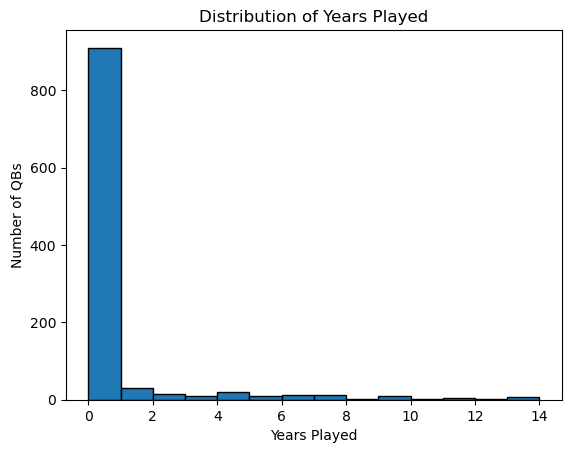

In [1422]:
plt.hist(cfb_nfl_dataset['years_played'], bins=14, edgecolor='black')
plt.title("Distribution of Years Played")
plt.xlabel("Years Played")
plt.ylabel("Number of QBs")
plt.show()

From this plot, you can see that the vast majority of college quarterbacks do not play in the NFL. This also shows that there is likely a lot of skew across the dataset. I will have to deal with that before clustering.

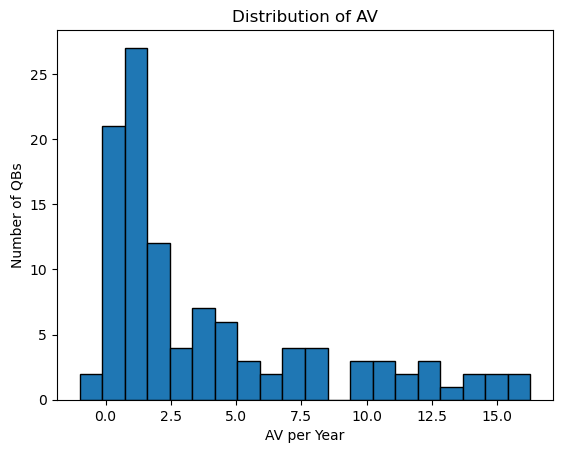

In [1424]:
filtered_data = cfb_nfl_dataset["av_per_year"][cfb_nfl_dataset["av_per_year"] != 0]
plt.hist(filtered_data, bins=20, edgecolor='black')
plt.title("Distribution of AV")
plt.xlabel("AV per Year")
plt.ylabel("Number of QBs")
plt.show()

This plot shows that the majority of quarterbacks who do make the NFL do not make much of an impact. You will notice a negative value. This is possible but very rare. Only the very worst quarterbacks are able to perform so badly that they accumulate negative AV.

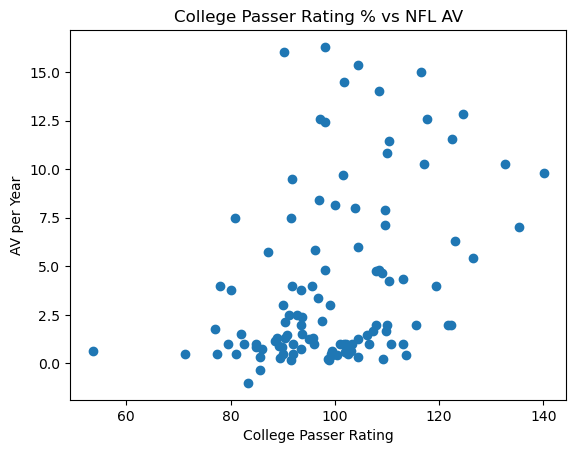

In [1426]:
filtered_data = cfb_nfl_dataset[cfb_nfl_dataset["av_per_year"] != 0]
plt.scatter(filtered_data['passer_rating'], filtered_data['av_per_year'])
plt.title("College Passer Rating % vs NFL AV")
plt.xlabel("College Passer Rating")
plt.ylabel("AV per Year")
plt.show()

This scatter plot shows that there could be a small correlation between college passer rating and NFL success. This makes sense as a combination of efficiency stats should translate well to the next level.

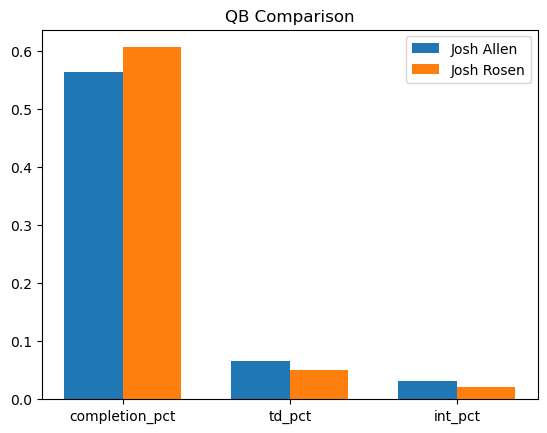

In [1428]:
Allen = cfb_nfl_dataset[cfb_nfl_dataset["Clean_Name"] == "josh allen"].iloc[0]
Rosen = cfb_nfl_dataset[cfb_nfl_dataset["Clean_Name"] == "josh rosen"].iloc[0]

metrics = ['completion_pct', 'td_pct', 'int_pct']
values1 = [Allen[m] for m in metrics]
values2 = [Rosen[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, values1, width, label='Josh Allen')
plt.bar(x + width/2, values2, width, label='Josh Rosen')

plt.xticks(x, metrics)
plt.title("QB Comparison")
plt.legend()
plt.show()

When plotting some of the components of passer rating for two quarterbacks named Josh from the 2019 draft, the plot casts doubt on a simple passer rating analysis. Allen just won the MVP, while Rosen is a notorious bust. Surprisingly, Rosen seems the better prospect based on two key statistics: percentage of passes that were caught and percentage of passes that were intercepted (lower is better). We have to go beyond statistics to solve this issue.

# 5.0 Prepping Data for Cluster Analysis and more EDA

In [1431]:
# dropping columns that would allow NFL results to bleed into the model. I am keeping AV in the dataset to use as a binary for clustering
result_columns = ['av_per_year', 'years_played', 'G', 'GS', 'from_year_nfl', 'to_year_nfl', 'Draft Year', 'Draft Team', 'draft_age', 'Round', 'Pick', 'nfl_team']
standard_data = cfb_nfl_dataset.drop(columns=result_columns)
# dropping ordinal data that is not needed for clustering 
standard_data.drop(['combine_season', 'from_year', 'to_year', 'Clean_Name'], axis=1, inplace = True)

# function to convert height in format "6-0" to inches
def height_to_inches(height_str):
    try:
        feet, inches = height_str.split('-') # See citation 2
        return int(feet) * 12 + int(inches)
    except:
        return None

standard_data['ht'] = standard_data['ht'].apply(height_to_inches)

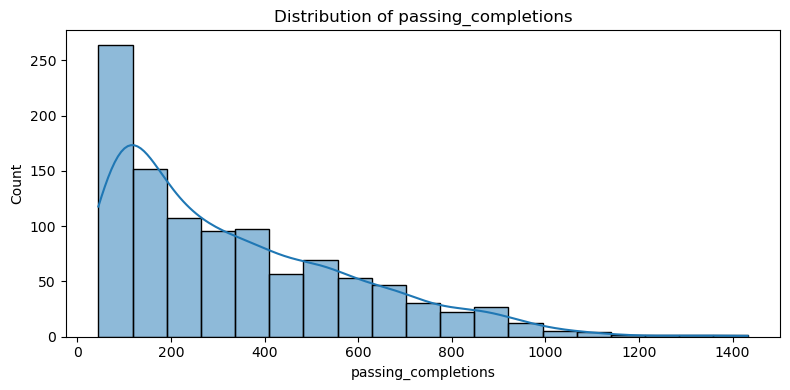

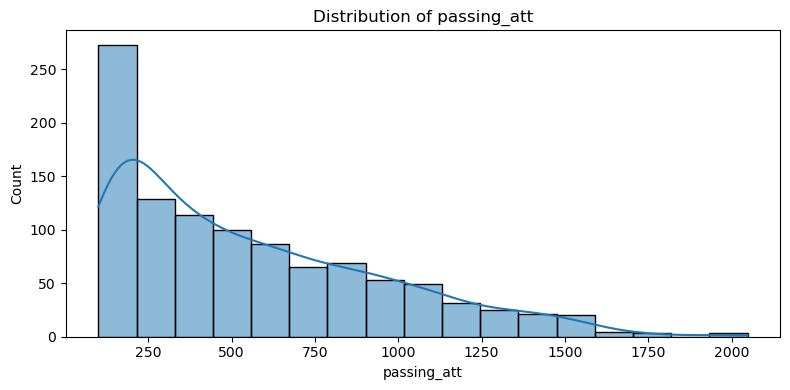

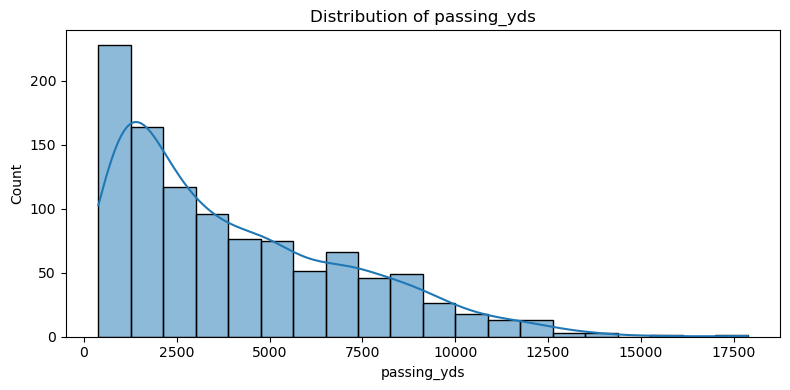

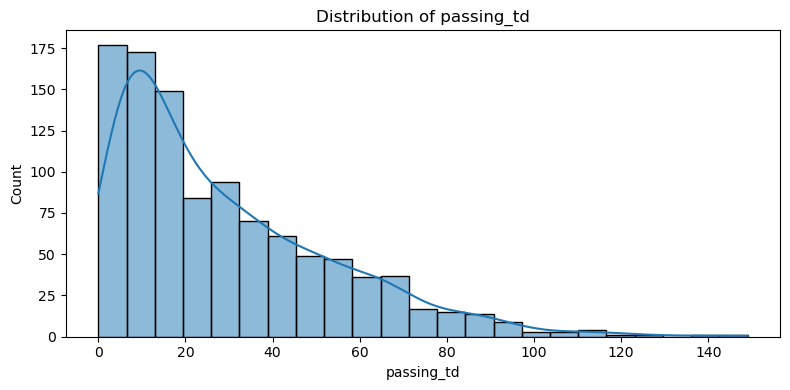

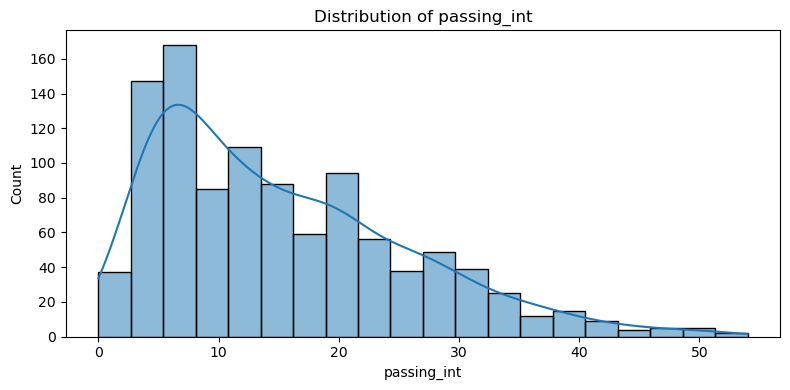

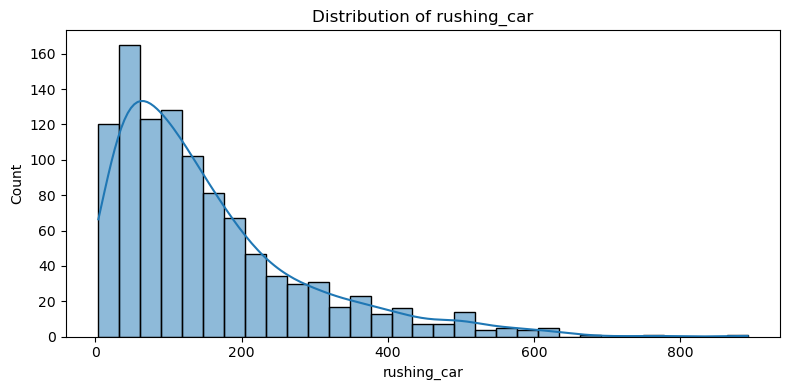

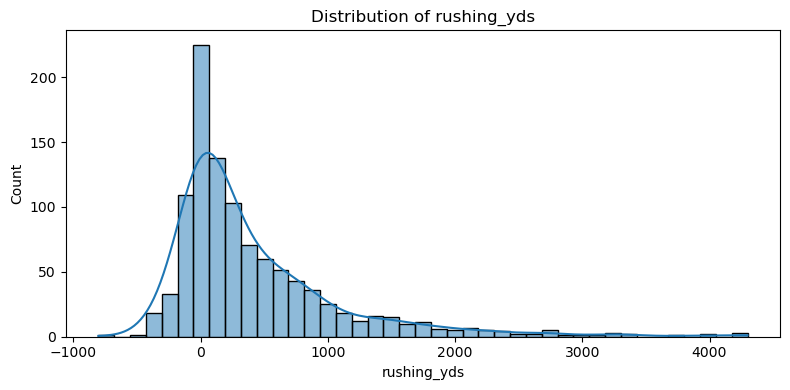

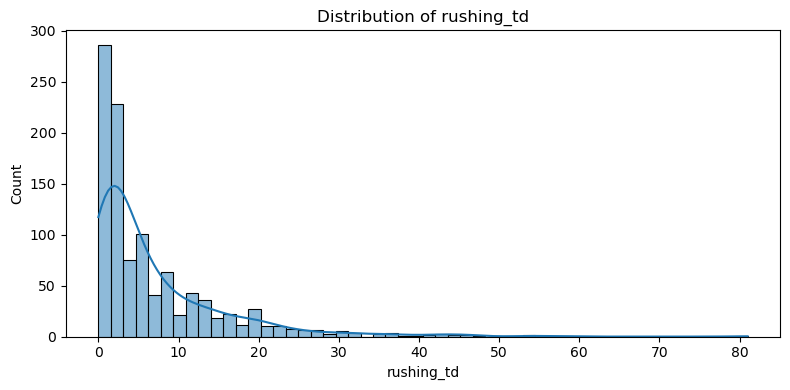

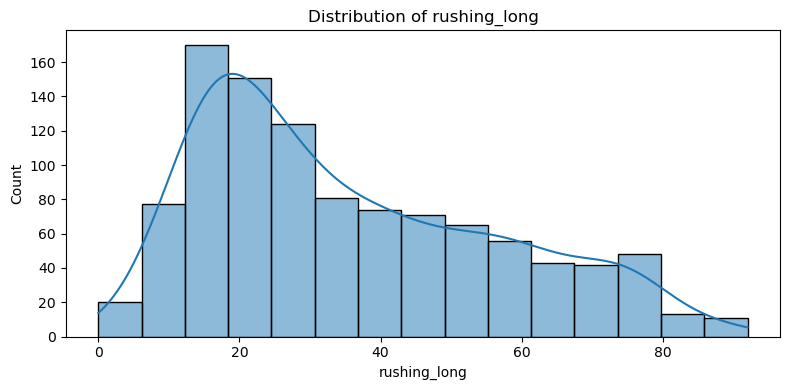

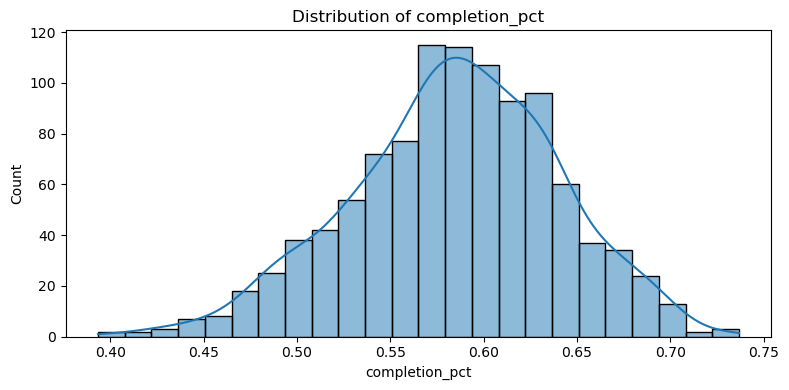

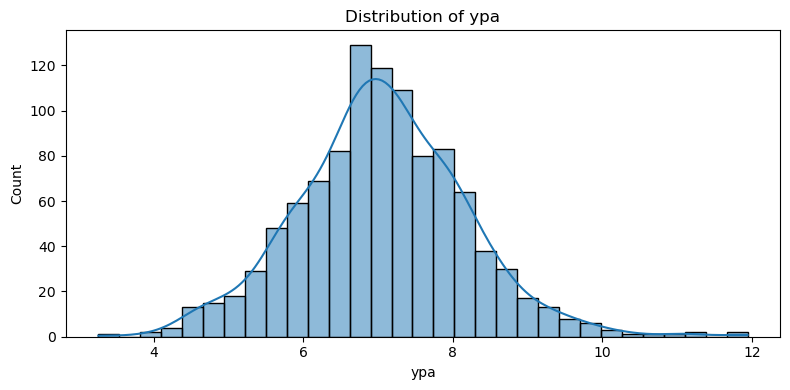

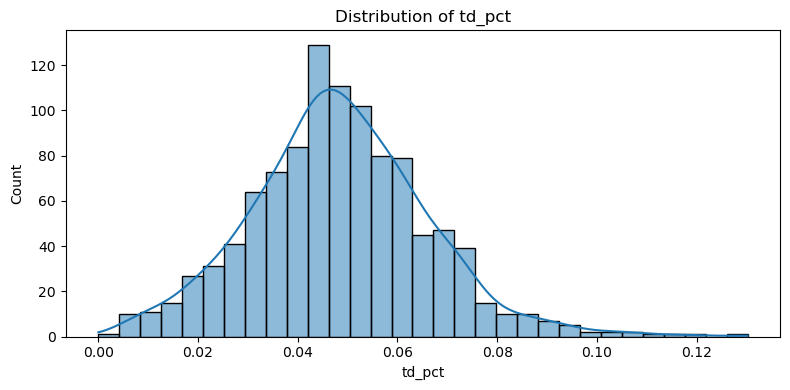

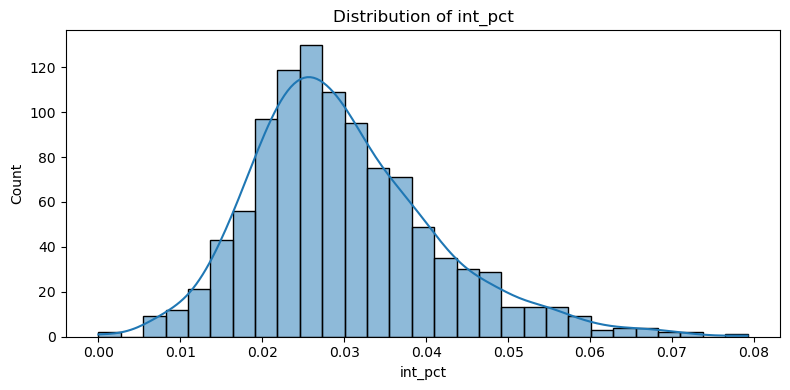

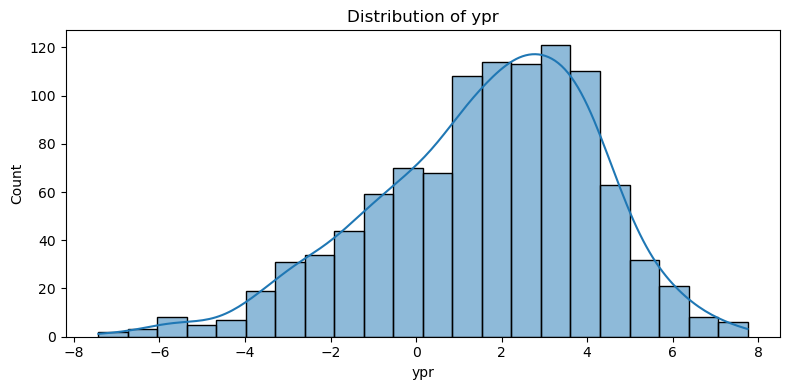

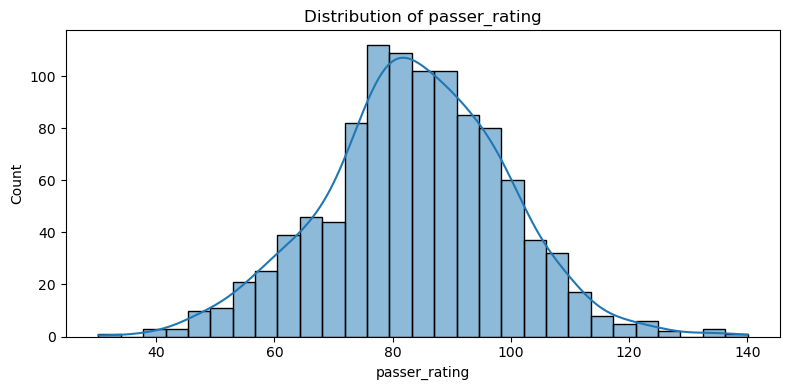

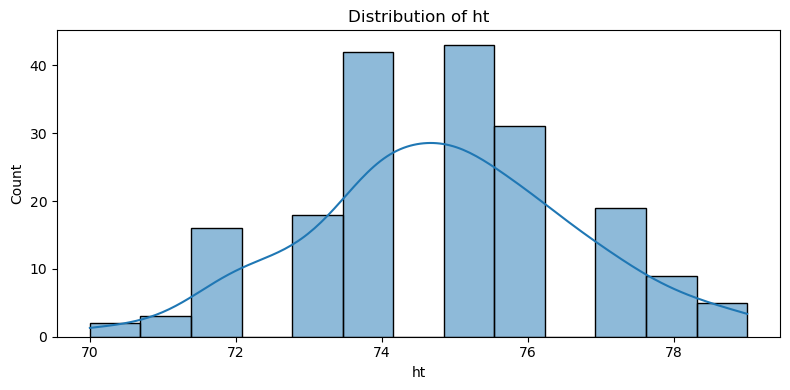

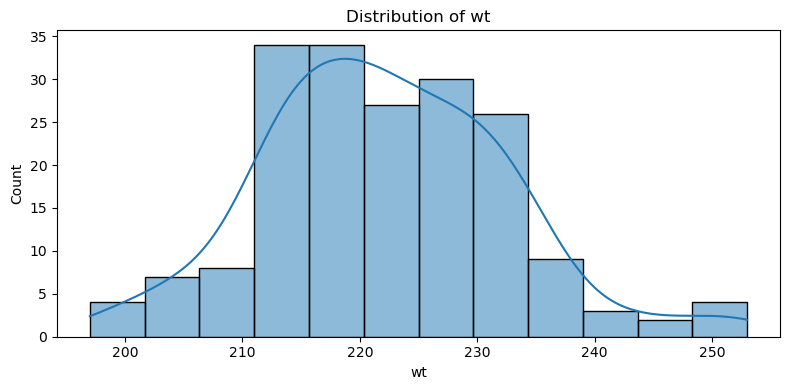

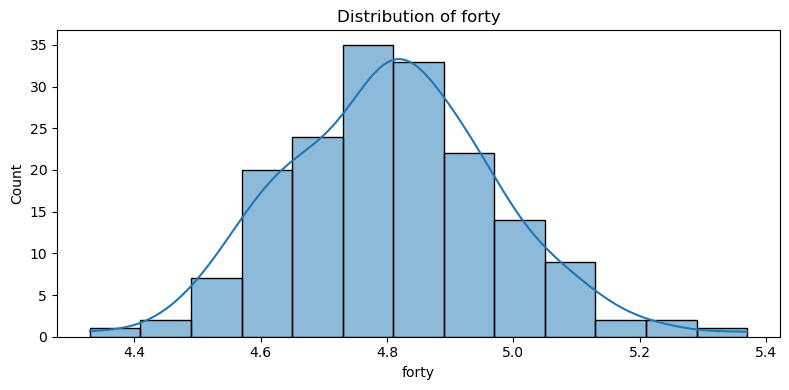

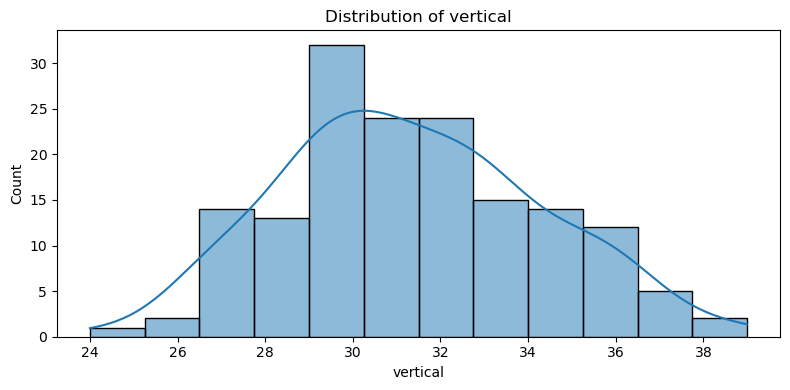

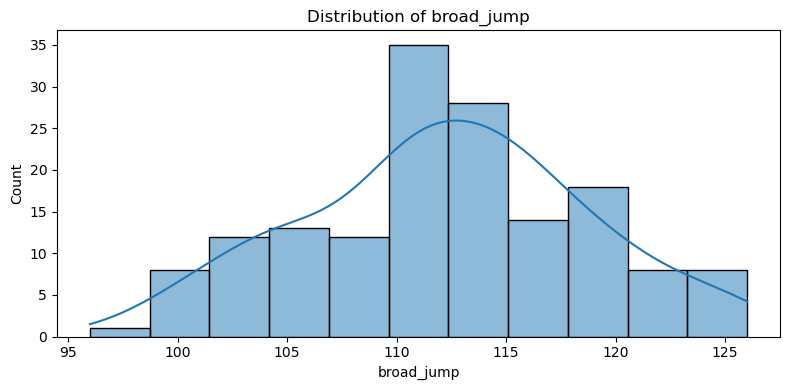

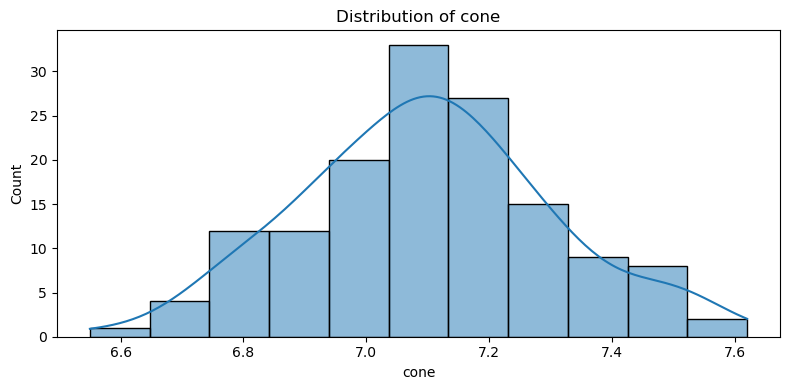

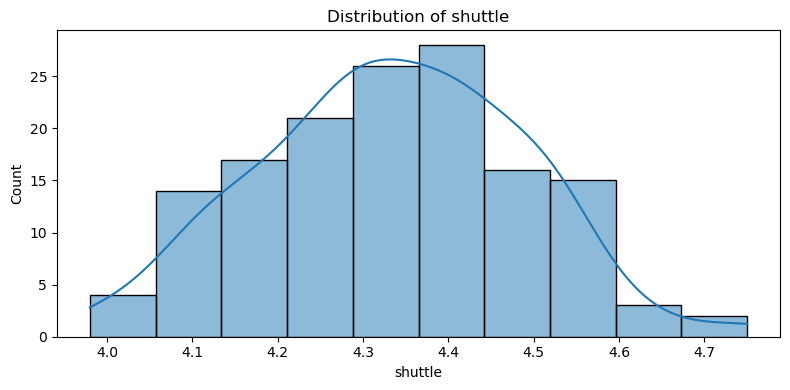

In [1432]:
numeric_columns = standard_data.select_dtypes(include = 'number').columns.tolist()
numeric_columns.remove('athlete_id')
numeric_columns.remove('AV')
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=standard_data, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

Most of the data here is skewed to the left as expected. Most quarterbacks have low levels of most statistics. Interestingly, the rate statistics are more normally distributed. Below, I will check the skew of the data.

In [1434]:
standard_data['nfl_success'] = (standard_data['AV'] >= 30).astype(int)
standard_data.drop(columns='AV', inplace=True)
skewed_columns = standard_data[numeric_columns].skew().sort_values(ascending = False)
print(skewed_columns)

rushing_td             2.623386
rushing_yds            2.288006
rushing_car            1.560604
passing_td             1.237019
passing_completions    1.018818
passing_yds            0.961590
passing_int            0.934884
passing_att            0.920269
int_pct                0.802007
rushing_long           0.656511
td_pct                 0.361267
wt                     0.324108
ypa                    0.245021
vertical               0.211001
forty                  0.196710
cone                   0.116416
ht                     0.002501
shuttle               -0.000068
passer_rating         -0.024587
broad_jump            -0.064881
completion_pct        -0.260001
ypr                   -0.550787
dtype: float64


Using a threshold of +/- 1 for adjusting skew, I will be using yeo johnson to unskew the data because there may be negative values.

In [1436]:
high_skew_columns = skewed_columns[abs(skewed_columns) > 1].index.tolist()
pt = PowerTransformer(method='yeo-johnson')
standard_data.loc[:, high_skew_columns] = pt.fit_transform(standard_data[high_skew_columns])
skewed_columns = standard_data[numeric_columns].skew().sort_values(ascending = False)
print(skewed_columns)

passing_yds            0.961590
passing_int            0.934884
passing_att            0.920269
int_pct                0.802007
rushing_long           0.656511
rushing_yds            0.396140
td_pct                 0.361267
wt                     0.324108
ypa                    0.245021
vertical               0.211001
forty                  0.196710
cone                   0.116416
rushing_td             0.013879
ht                     0.002501
shuttle               -0.000068
rushing_car           -0.023308
passer_rating         -0.024587
passing_completions   -0.026642
passing_td            -0.045021
broad_jump            -0.064881
completion_pct        -0.260001
ypr                   -0.550787
dtype: float64


The data is now in an acceptable range of skew.

In [1438]:
standard_data.loc[:, numeric_columns] = MinMaxScaler().fit_transform(standard_data[numeric_columns])
standard_data.head()

,athlete_id,passing_completions,passing_att,passing_yds,passing_td,passing_int,rushing_car,rushing_yds,rushing_td,rushing_long,...,ypr,passer_rating,ht,wt,forty,vertical,broad_jump,cone,shuttle,nfl_success
0,132870,0.269403,0.062628,0.076738,0.434714,0.055556,0.434976,0.594135,0.173003,0.391304,...,0.791795,0.617099,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,136354,0.238190,0.052875,0.050034,0.356188,0.074074,0.287292,0.543987,0.271327,0.163043,...,0.524291,0.465788,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,160307,0.822295,0.601129,0.584744,0.851740,0.722222,0.592929,0.571747,0.470166,0.336957,...,0.564208,0.651666,0.333333,0.214286,0.490385,0.533333,0.2,0.485981,0.480519,0
4,160603,0.249717,0.055955,0.059412,0.315234,0.092593,0.531512,0.596346,0.339831,0.228261,...,0.683946,0.445788,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
5,162068,0.213692,0.055955,0.052379,0.406377,0.074074,0.370327,0.556386,0.339831,0.217391,...,0.597219,0.459765,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


I used MinMaxScaler to scale numeric data to a 0-1 range. The raw data ranges from small percentages to thousands of passing yards. This will allow for easier analysis.

In [1440]:
#Hashing categorical Columns
conference_features = 128
conference_dictionary = standard_data[['conference']].astype(str).to_dict(orient='records')
conference_hash = FeatureHasher(n_features=conference_features, input_type='dict')
hashed_conference = conference_hash.transform(conference_dictionary).toarray()

college_features = 256
college_dictionary = standard_data[['college_team']].astype(str).to_dict(orient='records')
college_hash = FeatureHasher(n_features=college_features, input_type='dict')
hashed_college = college_hash.transform(college_dictionary).toarray()

hashed_combined = np.hstack([hashed_college, hashed_conference]) # See citation 3
n_components = 50 
pca = PCA(n_components=n_components, random_state = 42)
college_pca = pca.fit_transform(hashed_combined)
hashed_df = pd.DataFrame(college_pca, columns=[f'pca_feature_{i}' for i in range(n_components)])

standard_data = pd.concat([standard_data.drop(columns=['conference', 'college_team']).reset_index(drop=True), hashed_df.reset_index(drop=True)], axis=1)

standard_data.columns = standard_data.columns.astype(str)
standard_data.head()

,athlete_id,passing_completions,passing_att,passing_yds,passing_td,passing_int,rushing_car,rushing_yds,rushing_td,rushing_long,...,pca_feature_40,pca_feature_41,pca_feature_42,pca_feature_43,pca_feature_44,pca_feature_45,pca_feature_46,pca_feature_47,pca_feature_48,pca_feature_49
0,132870,0.269403,0.062628,0.076738,0.434714,0.055556,0.434976,0.594135,0.173003,0.391304,...,0.015493,-0.001030,-0.012159,-0.001048,0.012129,-0.017166,-0.009517,-0.013171,0.005064,-0.015912
1,136354,0.238190,0.052875,0.050034,0.356188,0.074074,0.287292,0.543987,0.271327,0.163043,...,-0.138889,0.044801,0.108283,-0.054496,0.073224,0.122472,0.047671,0.107430,-0.221730,-0.158014
2,160307,0.822295,0.601129,0.584744,0.851740,0.722222,0.592929,0.571747,0.470166,0.336957,...,0.001970,0.004884,-0.063274,0.002685,0.023603,-0.031720,-0.033565,0.021631,-0.158502,-0.025404
3,160603,0.249717,0.055955,0.059412,0.315234,0.092593,0.531512,0.596346,0.339831,0.228261,...,0.008302,0.001001,-0.064789,-0.011012,0.020016,-0.052938,-0.017557,0.004809,-0.045039,0.020694
4,162068,0.213692,0.055955,0.052379,0.406377,0.074074,0.370327,0.556386,0.339831,0.217391,...,0.053224,0.003590,-0.105852,-0.043693,-0.003177,-0.002574,-0.043950,0.017259,-0.012620,0.003997


I used FeatureHasher to hash both categorical variables. I used 128 features for conference because there are 143 in the dataset. I used 256 because there are 406 unique college values. However, I was concerned that 386 hashed columns would overwhelm my dataset. I used PCA to reduce dimensionality to 50 columns.

In [1442]:
standard_data = standard_data.astype('float64')
combine_columns = ['ht', 'wt', 'forty', 'vertical', 'broad_jump', 'cone', 'shuttle']
for col in combine_columns:
    standard_data[col] = standard_data[col].fillna(-1)

I filled combine column N/As with -1 to help the cluster algorithm make sense of the missing values. I am skeptical that this data will work out because there are so many missing values.

# 6.0 Cluster Analysis

In [1445]:
athlete_ids = standard_data['athlete_id'].copy() #saving for later
cluster_data = standard_data.drop(['athlete_id'], axis = 1)
covariance = np.cov(np.transpose(cluster_data))
eigenvalues = np.linalg.eigvals(covariance)
eigengaps = -np.diff(eigenvalues)
eigengap_ratio = np.divide(eigengaps, eigenvalues[:-1])

nan = [np.nan]
pd.DataFrame({'Eigenvalues':eigenvalues,
             'Eigengaps':np.concatenate((eigengaps,nan),axis=0),   
             'Eigengap_Eigenvalue_ratio':np.concatenate((eigengap_ratio,nan),axis=0)})

,Eigenvalues,Eigengaps,Eigengap_Eigenvalue_ratio
0,2.001136,1.790310,0.894647
1,0.210826,0.074310,0.352471
2,0.136516,0.027284,0.199857
3,0.109232,0.015021,0.137511
4,0.094212,0.011486,0.121915
...,...,...,...
68,0.010773,-0.000071,-0.006622
69,0.010844,-0.000100,-0.009221
70,0.010944,-0.000130,-0.011849
71,0.011074,-0.000101,-0.009127


There is a pretty big gap between the first two components. This may show that a low number of clusters is best.

In [1447]:
np.random.seed(4365)
reducer = umap.UMAP()
cluster_embedding = reducer.fit_transform(cluster_data)

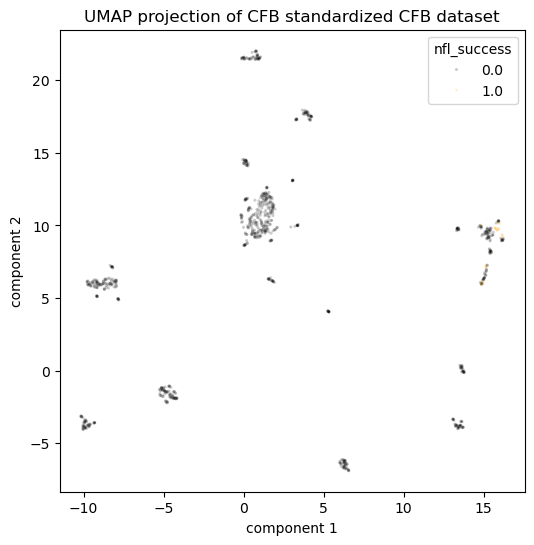

In [1448]:
cluster_embedding_df = pd.DataFrame(cluster_embedding, columns = ['component1', 'component2'])
cluster_embedding_df['nfl_success'] = cluster_data['nfl_success'].values

fig,ax = plt.subplots(figsize=(6,6))
sns.scatterplot(data=cluster_embedding_df, x='component1', y='component2', 
                hue='nfl_success', style='nfl_success', markers=['o','v'],
                s=5, alpha=0.2, ax=ax, palette={0:'black', 1:'orange'} )
ax.set_xlabel('component 1');
ax.set_ylabel('component 2');
ax.set_title('UMAP projection of CFB standardized CFB dataset');

This is a very interesting looking cluster plot. The data is clumped very tightly and there is a lot of distance between the clusters. I will start off with Agglomeratve Clustering because K-means clustering does not seem promising given the nature of my data. 

In [1450]:
nr.seed(2356)
if 'cluster_assignments' in cluster_data.columns: cluster_data.drop(columns='cluster_assignments', inplace=True)
model_agglomerative =  AgglomerativeClustering(n_clusters=4, linkage='complete', metric='manhattan',
                                              compute_full_tree=False)   
cluster_data['cluster_assignments'] = model_agglomerative.fit_predict(cluster_data)
cluster_data.loc[:,['cluster_assignments','nfl_success']].value_counts().sort_index(axis=0, level=0)

cluster_assignments  nfl_success
0                    0.0            859
                     1.0              2
1                    0.0             95
                     1.0             24
2                    0.0             25
                     1.0              7
3                    0.0             30
                     1.0              4
Name: count, dtype: int64

I am struggling to see any useful patterns with this data. No clusters with a higher than normal amount of successful exist. I also do not want to go much farther without dropping the combine data, as I am confident that it is harming my analysis. I will plot these clusters blow for comparison

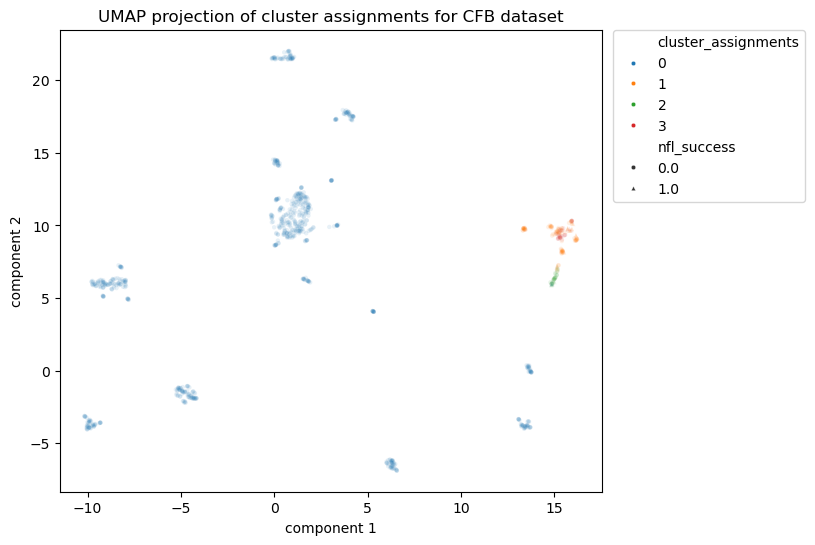

In [1452]:
def plot_cluster_assignments(df, cluster_assignments):
    if 'lift' in cluster_embedding_df.columns: cluster_embedding_df.drop(['nfl_success'], axis=1, inplace=True)
    df['cluster_assignments'] = cluster_assignments.astype('category')
    fig,ax = plt.subplots(figsize=(7,6))
    sns.scatterplot(data=df, x='component1', y='component2', 
                    hue='cluster_assignments', style='nfl_success', 
                    markers=['o','^'], s=10, alpha=0.1, ax=ax);
    legend = ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    for handle in legend.legend_handles:
        handle.set_alpha(1.0)  
    ax.set_xlabel('component 1');
    ax.set_ylabel('component 2');
    ax.set_title('UMAP projection of cluster assignments for CFB dataset');

plot_cluster_assignments(cluster_embedding_df, cluster_data['cluster_assignments'])

Cluster 2 covers most of the data and is very spread out. After dropping the combine data, I will use silhouette score to find the optimal number of clusters.

In [1454]:
cluster_data.drop(combine_columns, axis=1, inplace = True)
covariance = np.cov(np.transpose(cluster_data))
eigenvalues = np.linalg.eigvals(covariance)
eigengaps = -np.diff(eigenvalues)
eigengap_ratio = np.divide(eigengaps, eigenvalues[:-1])

nan = [np.nan]
pd.DataFrame({'Eigenvalues':eigenvalues,
             'Eigengaps':np.concatenate((eigengaps,nan),axis=0),   
             'Eigengap_Eigenvalue_ratio':np.concatenate((eigengap_ratio,nan),axis=0)})

,Eigenvalues,Eigengaps,Eigengap_Eigenvalue_ratio
0,0.538582,0.336884,0.625501
1,0.201699,0.065765,0.326054
2,0.135934,0.043004,0.316357
3,0.092930,0.009323,0.100325
4,0.083607,0.007696,0.092044
...,...,...,...
62,0.011190,0.000112,0.009973
63,0.011079,0.000287,0.025885
64,0.010792,-0.000090,-0.008383
65,0.010882,-0.000061,-0.005639


The structure of these eigenvalues is similar although the values are now much smaller. The drop in eigengap after the first value is much less extreme than before.

In [1456]:
np.random.seed(4365)
reducer = umap.UMAP()
cluster_embedding = reducer.fit_transform(cluster_data)

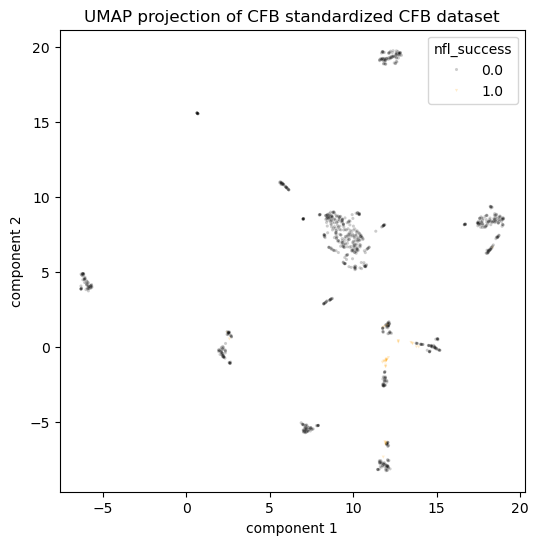

In [1457]:
cluster_embedding_df = pd.DataFrame(cluster_embedding, columns = ['component1', 'component2'])
cluster_embedding_df['nfl_success'] = cluster_data['nfl_success'].values

fig,ax = plt.subplots(figsize=(6,6))
sns.scatterplot(data=cluster_embedding_df, x='component1', y='component2', 
                hue='nfl_success', style='nfl_success', markers=['o','v'],
                s=5, alpha=0.2, ax=ax, palette={0:'black', 1:'orange'} ) # palette=sns.color_palette("rocket"));
ax.set_xlabel('component 1');
ax.set_ylabel('component 2');
ax.set_title('UMAP projection of CFB standardized CFB dataset');

This graph looks slightly better than before. The clusters are still well defined but a bit less scattered.

In [1459]:
nr.seed(2356)
if 'cluster_assignments' in cluster_data.columns: cluster_data.drop(columns='cluster_assignments', inplace=True)
model_agglomerative =  AgglomerativeClustering(n_clusters=4, linkage='complete', metric='manhattan',
                                              compute_full_tree=False)   
cluster_data['cluster_assignments'] = model_agglomerative.fit_predict(cluster_data)
cluster_data.loc[:,['cluster_assignments','nfl_success']].value_counts().sort_index(axis=0, level=0)

cluster_assignments  nfl_success
0                    0.0            451
                     1.0             17
1                    0.0            417
                     1.0              4
2                    0.0            127
                     1.0             15
3                    0.0             14
                     1.0              1
Name: count, dtype: int64

The positive values are still pretty evenly spread through the clusters. More clusters are likely needed.

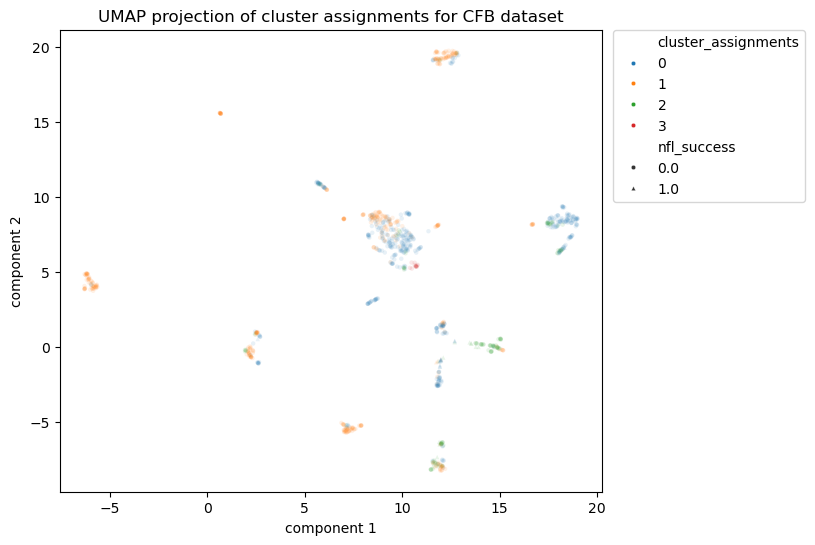

In [1461]:
plot_cluster_assignments(cluster_embedding_df, cluster_data['cluster_assignments'])

The plot also reflects this analysis.

,NumberClusters,ClusterDiameter,SilhouetteCoefficient
0,4,17.211996,0.034023
1,5,16.567228,0.045820
2,6,16.429035,0.043986
3,7,16.308072,0.052442
4,8,16.263954,0.063903
5,9,15.586812,0.057941
6,10,15.523536,0.063034
7,11,15.030508,0.075578
8,12,14.978215,0.078609
9,13,14.966303,0.085476


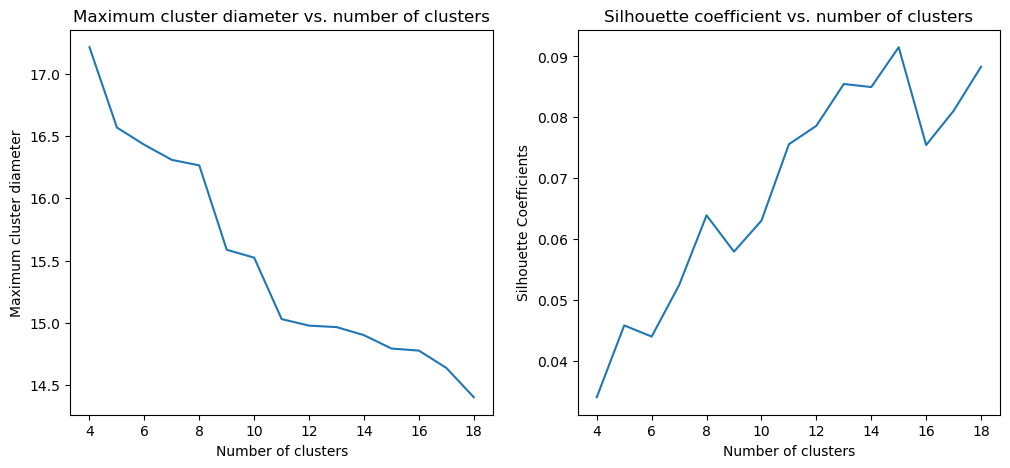

In [1463]:
def find_max_diameter(df, metric='manhattan'):
    max_diameters = []
    cluster_labels = df['cluster_assignments'].unique()
    for label in cluster_labels:
        temp_df = df[df['cluster_assignments'] == label].drop(columns = 'cluster_assignments')
        distances = pairwise_distances(temp_df, metric = metric)
        max_distance = np.amax(distances)
        max_diameters.append(max_distance)
    return max(max_diameters)
    

def evaluate_agglomerative_clusters(df, metric='manhattan', linkage='complete', nclusts=(4,18)): 
    silhouette_coefficients = []
    max_diameters = []
    df = df.drop(columns = 'cluster_assignments')
    for k in range(nclusts[0],nclusts[1]+1):
        model = AgglomerativeClustering(n_clusters = k, metric = metric, linkage = linkage)
        cluster_labels = model.fit_predict(df)
        df['cluster_assignments'] = cluster_labels
        sil_score = silhouette_score(df.drop(columns='cluster_assignments'), cluster_labels, metric=metric)
        silhouette_coefficients.append(sil_score)
        max_diameter = find_max_diameter(df, metric=metric)
        max_diameters.append(max_diameter)
        

    ## Plot the results     
    _, ax = plt.subplots(1,2, figsize=(12,5))    
    ax[0].plot(range(nclusts[0],nclusts[1]+1), max_diameters);
    ax[0].set_xlabel('Number of clusters')
    ax[0].set_ylabel('Maximum cluster diameter')
    ax[0].set_title('Maximum cluster diameter vs. number of clusters')
    ax[1].plot(range(nclusts[0],nclusts[1]+1), silhouette_coefficients);
    ax[1].set_xlabel('Number of clusters')
    ax[1].set_ylabel('Silhouette Coefficients')
    ax[1].set_title('Silhouette coefficient vs. number of clusters')
    return pd.DataFrame({'NumberClusters':range(nclusts[0],nclusts[1]+1),
                         'ClusterDiameter':max_diameters ,
                         'SilhouetteCoefficient':silhouette_coefficients})  

evaluate_agglomerative_clusters(cluster_data)    

The Silhouette coefficient peaks at 15. There seems to be a small change in the slope of the cluster diameter as well. I will try 15 clusters.

In [1465]:
nr.seed(2356)
if 'cluster_assignments' in cluster_data.columns: cluster_data.drop(columns='cluster_assignments', inplace=True)
model_agglomerative =  AgglomerativeClustering(n_clusters= 15, linkage='complete', metric='manhattan',
                                              compute_full_tree=False)   
cluster_data['cluster_assignments'] = model_agglomerative.fit_predict(cluster_data)
cluster_data.loc[:,['cluster_assignments','nfl_success']].value_counts().sort_index(axis=0, level=0)

cluster_assignments  nfl_success
0                    0.0            226
                     1.0             10
1                    0.0            130
                     1.0              1
2                    0.0             79
                     1.0              6
3                    0.0             14
                     1.0              1
4                    0.0             33
                     1.0              1
5                    0.0             36
                     1.0              6
6                    0.0             24
                     1.0              1
7                    0.0             38
                     1.0              4
8                    0.0            159
                     1.0              1
9                    0.0            112
                     1.0              2
10                   0.0            106
                     1.0              1
11                   0.0             12
                     1.0              3
12     

11, 5, and 7 are standing out with a higher proportion of successes, but still not many. I will try Spectral clustering to see if I get better results.

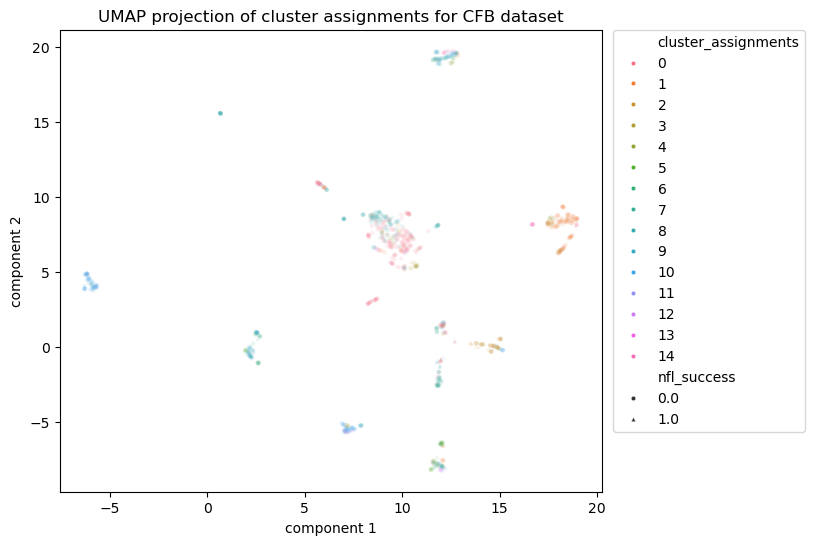

In [1467]:
plot_cluster_assignments(cluster_embedding_df, cluster_data['cluster_assignments'])

In [1468]:
#Spectral Clustering
nr.seed(7788)
if 'cluster_assignments' in cluster_data.columns: cluster_data.drop(columns='cluster_assignments', inplace=True)

%time spectral_model = SpectralClustering(assign_labels='discretize', n_clusters=15, affinity='nearest_neighbors', n_neighbors=50, random_state=0)
cluster_data['cluster_assignments'] = spectral_model.fit_predict(cluster_data)
cluster_data.loc[:,['cluster_assignments','nfl_success']].value_counts().sort_index(axis=0, level=0)

CPU times: user 71 μs, sys: 801 μs, total: 872 μs
Wall time: 901 μs


cluster_assignments  nfl_success
0                    0.0             60
                     1.0              1
1                    0.0             61
2                    0.0             84
3                    0.0             66
                     1.0              1
4                    0.0             54
                     1.0              2
5                    0.0             70
                     1.0              1
6                    0.0             82
7                    0.0             41
8                    0.0             66
                     1.0              1
9                    0.0            106
10                   0.0             23
11                   0.0            147
12                   0.0              3
                     1.0             31
13                   0.0            112
14                   0.0             34
Name: count, dtype: int64

Cluster 12 looks very promising. 91% of the players in that cluster were successful. This cluster also contains 84% of all successful values. I will perform further analysis on this cluster below.

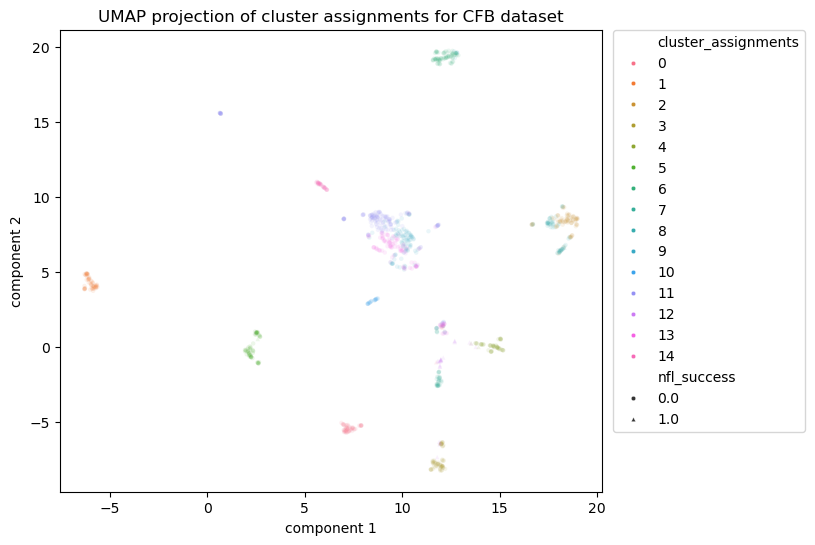

In [1470]:
plot_cluster_assignments(cluster_embedding_df, cluster_data['cluster_assignments'])

The clusters look much more defined than the plot with fewer clusters. Below I will look at some violin plots to examine cluster 12 against the other clusters.

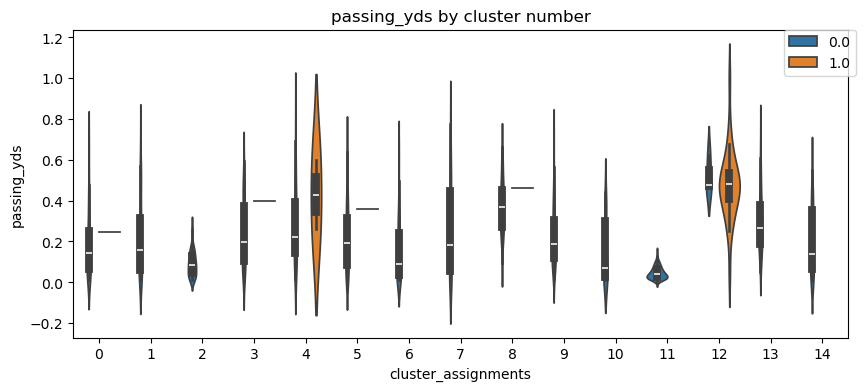

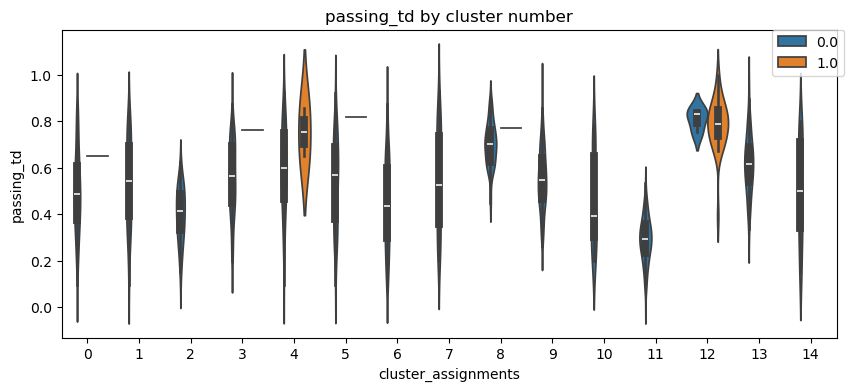

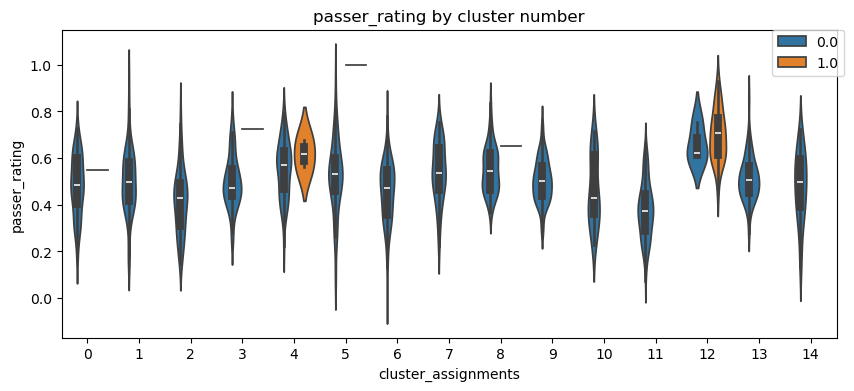

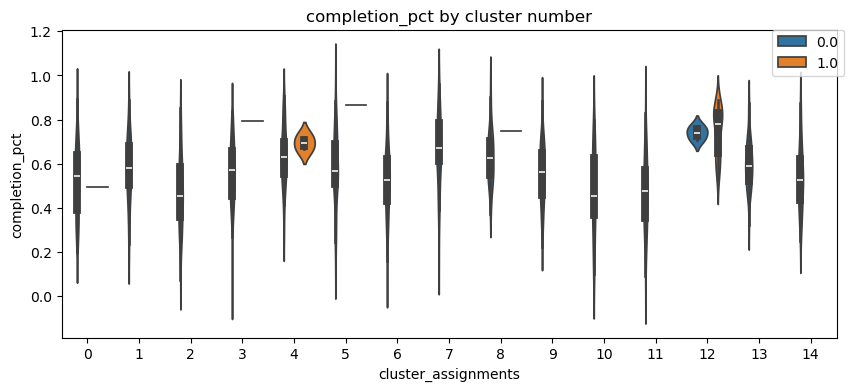

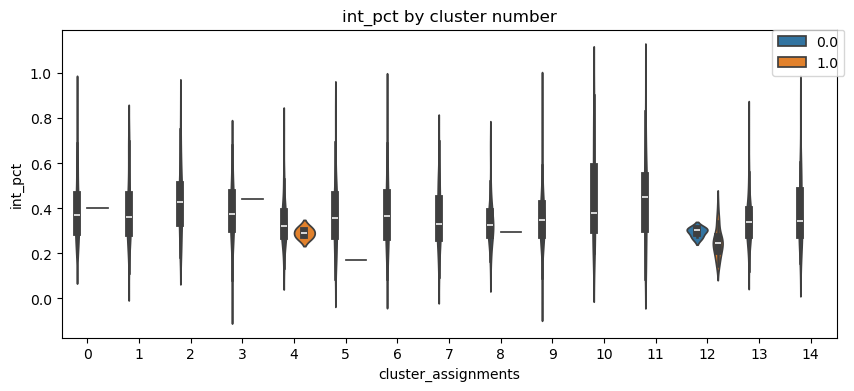

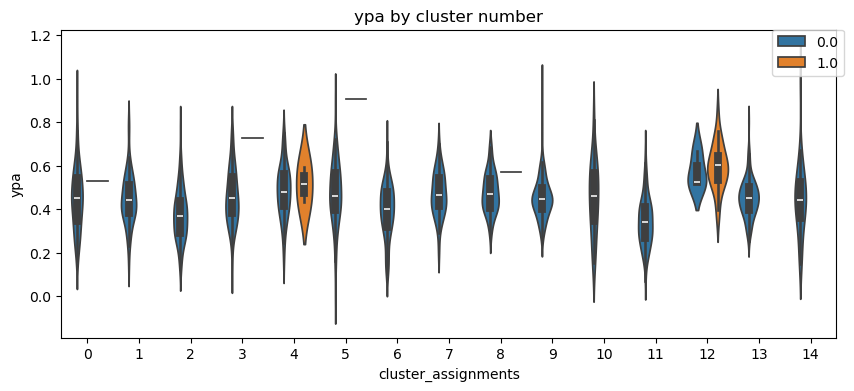

In [1472]:
def plot_clusters_by_factor(df, factor='passing_yds', type='violin'):
    plt.figure(figsize=(10,4))
    if(type=='violin'):
        ax=sns.violinplot(x='cluster_assignments', y=factor, hue='nfl_success', data=df, dodge=True)
    else: 
        ax=sns.boxplot(x='cluster_assignments', y=factor, hue='nfl_success', data=df)
    ax.set_title(factor + ' by cluster number')
    plt.legend(bbox_to_anchor=(1.01, 1), borderaxespad=0)
    
plot_columns = ['passing_yds','passing_td', 'passer_rating','completion_pct','int_pct', 'ypa']    
for factor in plot_columns:
    plot_clusters_by_factor(cluster_data, factor=factor)    

You can see from these plots that the players in cluster 12 are noticably higher in each stat outside of interception percentage (lower is better). These players seem to be high performers overall. There are so few unsuccessful players in the cluster that it is hard to take anything away from the differences within the cluster. Below I will do further analysis on cluster 12.

In [1474]:
cluster_data_new = pd.concat([athlete_ids, cluster_data], axis=1)
cluster_12_data = cluster_data_new[cluster_data_new['cluster_assignments'] == 12].copy()
other_clusters = cluster_data_new[cluster_data_new['cluster_assignments'] != 0]
comparison = pd.concat([
    cluster_12_data.drop(columns=['cluster_assignments', 'nfl_success', 'athlete_id']).mean().rename('cluster_12'),
    other_clusters.drop(columns=['cluster_assignments', 'nfl_success', 'athlete_id']).mean().rename('other_clusters')
], axis=1)

comparison['difference'] = comparison['cluster_12'] - comparison['other_clusters']
threshold = 0.15
important_differences = comparison[comparison['difference'].abs() >= threshold]
print(important_differences.sort_values(by='difference', ascending=False))

                     cluster_12  other_clusters  difference
passing_completions    0.740523        0.459945    0.280578
passing_td             0.787440        0.514059    0.273381
passing_yds            0.480639        0.210470    0.270169
passing_att            0.491560        0.234523    0.257037
rushing_td             0.593447        0.377284    0.216162
passer_rating          0.693170        0.488259    0.204911
completion_pct         0.744460        0.558264    0.186195
td_pct                 0.542764        0.370626    0.172138
ypa                    0.591188        0.435665    0.155522
rushing_car            0.662511        0.507560    0.154951


For this chart, I compared mean statistics from cluster 12 with the means from all other data. I set a threshold of 15% and returned the statistics where the difference between the two groups was higher than that. It is not surprising what columns are included. These are all statistics that you would expect top quarterbacks to perform highly in. What is surprising is the data that is not incuded. Interceptions and interception percentage are not as significant as passing and rushing volume. Rushing TDs and rushing carries are included but rushing yards are not. This result would change the way I looked at a quarterback who took a lot of risks and ended up making some negative plays. I would be more likely to ignore that in favor of outstanding statistics overall.

In [1476]:
cluster_12_ids = cluster_12_data['athlete_id']
cluster_12_clean_name = cfb_nfl_dataset[cfb_nfl_dataset['athlete_id'].isin(cluster_12_ids)]
cluster_12_info = cluster_12_clean_name[['athlete_id', 'Clean_Name', 'AV', 'Round']]
print(cluster_12_info.sort_values(by='AV', ascending=False))

      athlete_id         Clean_Name     AV      Round
182       238093     russell wilson  188.0          3
416       484080         derek carr  119.0          2
66        183253        andy dalton  118.0          2
1435     3916387      lamar jackson  114.0          1
1032      547401         jared goff  113.0          1
637       512030       dak prescott  112.0          4
1080      550373     baker mayfield   81.0          1
238       380470        andrew luck   80.0          1
1448     3917315       kyler murray   77.0          1
1656     4040715        jalen hurts   75.0          2
1632     4038941     justin herbert   70.0          1
622       511459     marcus mariota   63.0          1
1216     3122840     deshaun watson   63.0          1
1426     3915511         joe burrow   63.0          1
447       488025         geno smith   57.0          2
462       499514    jimmy garoppolo   53.0          2
628       511614  teddy bridgewater   53.0          1
162       236838       tyrod

This is an incredibly interesting result and is exactly what I was looking for. You can see here that out of the 34 QBs in this cluster, 18 were drafted in the first round, as would be expected for a blue-chip QB. However, there were 6 that slipped to the second round, 4 that slipped to the 3rd, and 6 who fell even further. If you could identify a QB who fits in this cluster but has been missed by other teams for one reason or the other, you could find incredible value. The three unsuccessful QBs are also interesting, and it would be important to study negative results to find gaps in statistical analysis. There are many intangible reasons a player may fail in the NFL.

I will now run optics clustering on this cluster to determine if I can break it up even more.

In [1479]:
if 'cluster_assignments' in cluster_12_data.columns: cluster_12_data.drop(columns='cluster_assignments', inplace=True)
cluster_12_data.drop(columns='athlete_id', inplace=True)
optics_model = OPTICS(p=2, min_samples=4)
%time optics_model.fit(cluster_12_data)
cluster_labels = optics_model.labels_
cluster_12_data['cluster_assignments'] = cluster_labels
cluster_12_data.loc[:,['cluster_assignments','nfl_success']].value_counts().sort_index(axis=0, level=0)

CPU times: user 115 ms, sys: 4.41 ms, total: 119 ms
Wall time: 31.9 ms


cluster_assignments  nfl_success
-1                   1.0            10
 0                   0.0             3
                     1.0            16
 1                   1.0             5
Name: count, dtype: int64

It seems that the cluster is too small for OPTICS to return any meaningful results. I will try running OPTICS on the whole dataset and see if I get anything different from the spectral model.

In [1481]:
#Optic Clustering
nr.seed(4512)
if 'cluster_assignments' in cluster_data.columns: cluster_data.drop(columns='cluster_assignments', inplace=True)
optics_model =  OPTICS(p=2, min_samples=10)   
%time optics_model.fit(cluster_data)
cluster_labels = optics_model.labels_
cluster_data['cluster_assignments'] = cluster_labels
cluster_data.loc[:,['cluster_assignments','nfl_success']].value_counts().sort_index(axis=0, level=0)

CPU times: user 5.06 s, sys: 89.2 ms, total: 5.15 s
Wall time: 1.3 s


cluster_assignments  nfl_success
-1                   0.0            727
                     1.0             37
 0                   0.0             14
 1                   0.0             11
 2                   0.0             10
 3                   0.0             10
 4                   0.0             22
 5                   0.0             10
 6                   0.0             39
 7                   0.0             31
 8                   0.0             15
 9                   0.0             11
 10                  0.0             45
 11                  0.0             37
 12                  0.0             27
Name: count, dtype: int64

I tried many different min_samples and all resulted in the successful quarterbacks being sent to the -1 cluster. The amount of positives is just too small for OPTICS to function.

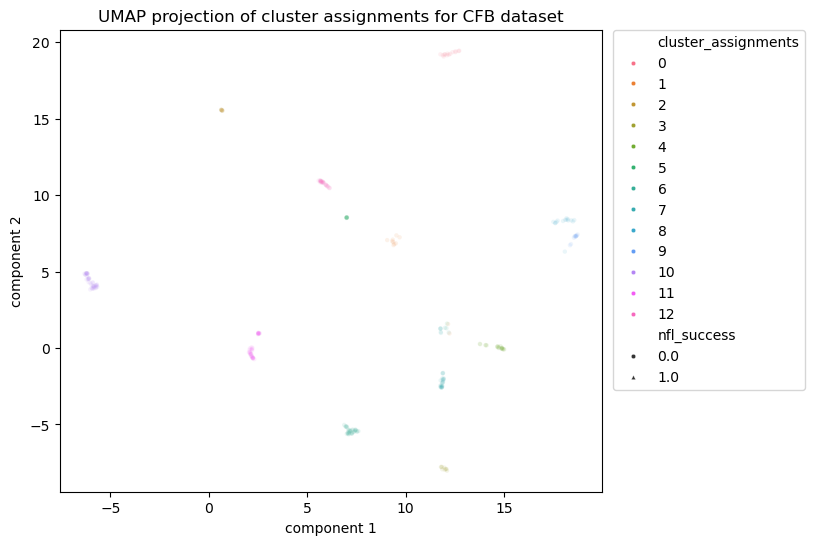

In [1483]:
cluster_temp = cluster_data[cluster_data.cluster_assignments > -1]
plot_cluster_assignments(cluster_embedding_df, cluster_temp['cluster_assignments'])

As hypothesized, it seems like there are too few positive examples that are too different from each other for OPTICS to work. I will move forward to similarity search and keep the spectral clustering results for my conclusion.

# 7.0 Similarity Search

I used a flat index similarity search because my dataset is small enough that it is still efficient.

In [1487]:
similarity_data = standard_data.drop(['athlete_id', 'nfl_success'], axis = 1).values.astype('float32')
index = faiss.IndexFlatL2(similarity_data.shape[1])
index.add(similarity_data)

In [1488]:
D, I = index.search(similarity_data[0:1], k=5)
print("Similar indices:", I)
print("Distances:", D)

Similar indices: [[  0 844 990 479 483]]
Distances: [[0.         0.05944252 0.24136579 0.8254471  0.82900685]]


The first two neighbors are pretty strong, then there is a drop-off in quality. 

In [1490]:
top_five = standard_data.iloc[I[0]]
standard_data_ids = top_five['athlete_id']
standard_data_clean_name = cfb_nfl_dataset[cfb_nfl_dataset['athlete_id'].isin(standard_data_ids)]
standard_data_info = standard_data_clean_name[['athlete_id', 'Clean_Name', 'AV', 'Round']]
print(standard_data_info.sort_values(by='AV', ascending=False))

      athlete_id        Clean_Name   AV Round
0         132870  martevious young  0.0   NaN
843       531770    anthony alford  0.0   NaN
849       532089        cole weeks  0.0   NaN
1639     4039275     kwadra griggs  0.0   NaN
2018     4362942      tate whatley  0.0   NaN


The actual data are QBs who I have never heard of and did not garner any draft buzz. I will have to specifically look for positive results to see how the similarity search is functioning.

In [1492]:
def find_similar_players(name, k=5):

    #converting given name from orignal dataset into athlete_id for lookup in the standardized dataset 
    player_id = cfb_nfl_dataset[cfb_nfl_dataset['Clean_Name'].str.contains(name)]['athlete_id'].values[0]
    #find that id in the standardized dataset
    player_row = standard_data[standard_data['athlete_id'] == player_id]
    #use the player id to create a vector for search
    player_vector = player_row.drop(columns=['athlete_id', 'nfl_success'], errors='ignore').values.astype('float32').reshape(1, -1)

    #perform the similarity search and return some useful data for analysis
    D, I = index.search(player_vector[0:1], k=k)
    similar_players = standard_data.iloc[I[0]].copy()
    similar_players['distance'] = D[0]
    similarity_df = similar_players.merge(cfb_nfl_dataset[['athlete_id', 'Clean_Name', 'AV', 'Round']], on='athlete_id', how='left')

    return similarity_df[['athlete_id', 'Clean_Name', 'AV', 'Round','distance']]

I created a simple function that allows you to input a player name and return the top five most similar players. The function pulls the athlete ID from the original dataframe, finds the row in the standardized df, converts it into a vector that can be searched, and performs a flat index similarity search.

In [1494]:
find_similar_players('trevor lawrence')

,athlete_id,Clean_Name,AV,Round,distance
0,4360310.0,trevor lawrence,41.0,1,0.000000
1,3916387.0,lamar jackson,114.0,1,1.499123
2,4037213.0,jamie newman,0.0,NaN,1.566782
3,3124900.0,jake luton,2.0,6,2.346297
4,3915511.0,joe burrow,63.0,1,2.384313


This is an interesting group. Lawrence is one of the greatest QB prospects of his generation. He is grouped with Lamar Jackson and Joe Burrow who are two of the other greatest college QBs of the last 25 years, but also two relatively obscure players.

In [1496]:
find_similar_players('josh allen')

,athlete_id,Clean_Name,AV,Round,distance
0,3918298.0,josh allen,112.0,1,0.000000
1,4036378.0,jordan love,30.0,1,1.531212
2,511889.0,jeff driskel,8.0,6,2.487679
3,4038220.0,cole mcdonald,0.0,NaN,2.528688
4,160307.0,max hall,1.0,Undrafted,2.540103


Josh Allen was a much more polarizing prospect and is grouped with Jordan Love who was thought of similarly when he came out of college. The knock on Josh Allen was that his stats were bad, but he had prototypical size. That would not be reflected in this analysis.

In [1498]:
find_similar_players('josh rosen')

,athlete_id,Clean_Name,AV,Round,distance
0,3886377.0,josh rosen,3.0,1,0.000000
1,3912547.0,sam darnold,42.0,1,0.730127
2,547401.0,jared goff,113.0,1,0.774701
3,3915436.0,steven montez,0.0,NaN,0.804127
4,513329.0,cody kessler,5.0,3,0.850550


Josh Rosen is a famous bust, one of the worst in recent memory. Sam Darnold was also thought of as a bust before a shocking breakout year last year after he had been cast aside. Jared Goff similarly was looked down upon after his first few years in the NFL but switched teams and made a major improvement last year. 

In [1500]:
find_similar_players('mac jones')

,athlete_id,Clean_Name,AV,Round,distance
0,4241464.0,mac jones,28.0,1,0.000000
1,191494.0,greg mcelroy,1.0,7,0.440208
2,480215.0,aj mccarron,4.0,5,0.841337
3,517475.0,johnny manziel,4.0,1,1.644293
4,4034946.0,kyle trask,0.0,2,1.729417


Here is an example of the feature hashing working well. Mac Jones played for Alabama in the SEC conference and was not that impressive. The similarity search returned two other Alabama QBs and four SEC QBs.

# 8.0 Conclusion

Overall, I accomplished many of the goals I set out in my proposal. I performed a cluster analysis and was able to analyse a cluster with a high proportion of successful quarterbacks. I wrote a similarity search function that allowed me to search for similar quarterbacks by inputting the player's name. The similarity search seemed to match reasonably well with what my domain knowledge would suggest. 

There were absolutely some limitations to my approach. I would have liked to have more data, including height/weight and advanced statistics. I believe these would have been valuable data points, but was unable to find a public dataset that contained enough of them. My analysis was also limited by the smaller size of my dataset, although I was looking at the full population. I could have included quarterbacks from further in the past, but the game has changed so much since then that it is not reasonable to compare a quarterback from the '90s to today's players.

If I were to take what I learned here and pursue this further, there are several items I would like to include. I would like to capture some datapoints for the college teams themselves. Offensive scheme, team quality, and quality of competition should be big indicators of future success. Some of that is likely included in the feature-hashing of conference and team, but I would like to analyse these items specifically. I would also like to analyse athletes invited to the combine separately and fold that in to my college data analysis. Finally, a separate but related question I would like to pursue is the "nature vs. nurture" debate. Are quarterbacks who succeed or fail doing so based on their skills or lack thereof? Or, are they dependent on the quality of the situation they are drafted into? I could combine my college data analysis with an analysis of NFL teams to further investigate this question.

In the end, I gleaned some interesting insights from my analysis. I located a cluster that was 91% made up of successful quarterbacks, and found that passing volume was more important than efficiency for that cluster. I was also surprised to find that interceptions were not among the most significant differences for that cluster. I also built a similarity search function that I can absolutely use and add to in my future draft analysis. With more data, it could become even more successful.

# Appendix

# Column explainations
1. **athlete_id**: A unique id returned by the R package that I pulled the college data with.
2. **passing_completions**: The number of passes thrown by the quarterback that were caught by a receiver.
3. **passing_att**: The number of passes thrown by the quarterback.
4. **passing_yds**: The number of yards thrown by the quarterback. Upon a completed pass, a quarterback is given credit for the yards gained from the line of scrimmage to where the receiver is tackled or scores.
5. **passing_td**: The number of touchdowns thrown by the quarterback.
6. **passing_int**: The number of passes thrown by the quarterback that were caught by a defender. (lower is better)
7. **rushing_car**: The number of times the quarterback ran the football. For college stats, sacks are included in this number.
8. **rushing_yds**: The number of yards the quarterback ran for with respect to the line of scrimmage. Since sacks are included, negative values are possible.
9. **rushing_td**: The number of touchdowns a quarterback scored by rushing.
10. **rushing_long**: The longest run relative to the line of scrimmage that the quarterback achieved in their career.
11. **from_year**: The first college season the quarterback recorded a statistic.
12. **to_year**: The final college season the quarterback recorded a statistic.
13. **college_team**: The college(s) the quarterback played for.
14. **conference**: The conference(s) the quarterback played in. A conference is a grouping of teams that play most of their games against each other. Teams were originally combined into conferences by proximity and team quality but now conferences are driven by television money.
15. **completion_pct**: Calculated column showing percentage of passes that were caught by a receiver. Used to measure accuracy.
16. **ypa**: Calculated column showing yards per pass attempt. Used to measure how agressive a quarterback is.
17. **td_pct**: Calculated column showing touchdowns per attempt.
18. **int_pct**: Calculated column showing interceptions per attempt (lower is better).
19. **ypr**: Calculated column showing yards per rush.
20. **passer_rating**: A commonly used calulation of overall efficiency that takes into account the rate stats above (#15-18). See [this link](https://en.wikipedia.org/wiki/Passer_rating) for calculation and history.
21. **Clean_Name**: Name of the quarterback.
22. **AV**: See link in section 2.0 Data
23. **Draft Team**: NFL team that drafted the quarterback if applicable.
24. **Round**: Round of the NFL draft the quarterback was selected in if applicable (1-7 or undrafted)
25. **Pick**: Pick of the NFL draft the quarterback was selected if applicable (minimum of 1, "first overall pick", maximum varies by year but is always between 250 and 270).
26. **Draft Year**: Year the quarterback was drafted if applicable.
27. **from_year_nfl**: First year the quarterback recorded a statistic in the NFL.
28. **to_year_nfl**: Final year the quarterback recorded a statistic in the NFL.
29. **draft_age**: Age of the quarterback when drafted.
30. **G**: NFL Games played.
31. **GS**: NFL games played as the starting quarterback
32. **nfl_team**: NFL team the quarterback played for in their final NFL season
33. **years_played**: Calculated column showing total years played in the NFL
34. **av_per_year**: Calculated column showing AV per year played.

# Citations
1. ChatGPT Query: "How do I aggregate a column when grouping rows in a pandas dataframe by a unique ID that has multiple values per ID. I want to keep each value and alphabetize it, separated by commas."
2. ChatGPT Query: How do I split a height string in the format "6-0" into numbers that I can convert to inches.
3. ChatGPT Query: What is a numpy function I can use to combine two feature-hashed arrays for PCA dimensionality reduction?